# Temperature Anomalies and Cereal Yields Across Countries

## Research Question

**How do temperature anomalies affect cereal yields across countries?**

This notebook combines:

1. **FAOSTAT cereal yield data**: country-year cereal yield in kg/ha.
2. **Our World in Data monthly temperature anomalies**: country-month temperature anomalies.

The pipeline follows a data engineering workflow:

1. Load raw CSV files.
2. Clean FAOSTAT yield data.
3. Aggregate monthly temperature anomalies to yearly country-level values.
4. Match and merge countries across both datasets using a two-layer strategy: ISO3/M49 code bridge first, normalised name matching as fallback.
5. Store the merged dataset in SQLite.
6. Query the database with SQL.
7. Visualise trends and relationships.
8. Engineer time-series features.
9. Run simple, explainable regression models.

> **Important note**: this project studies **association**, not strict causality. Cereal yields are affected by many factors besides temperature, including technology, irrigation, fertiliser use, conflicts, crop varieties, soil quality, and policy.



## GitHub setup

In [4]:
import os
import shutil
import subprocess
from getpass import getpass

USER = "juggo87"
EMAIL = "maxmeir@outlook.com"
REPO = "temperature-cereal-yield"
BRANCH = "main"

TOKEN = getpass("Geef je GitHub token in: ")

subprocess.run(["git", "config", "--global", "user.email", EMAIL], check=True)
subprocess.run(["git", "config", "--global", "user.name", USER], check=True)
subprocess.run(["git", "config", "--global", "init.defaultBranch", BRANCH], check=True)

repo_url = f"https://{TOKEN}@github.com/{USER}/{REPO}.git"
LOCAL_REPO = f"/content/{REPO}"

print("GitHub setup ready.")
print("Lokale repo map:", LOCAL_REPO)

Geef je GitHub token in: ··········
GitHub setup ready.
Lokale repo map: /content/temperature-cereal-yield


## Link Google Drive and select files

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DRIVE_FOLDER = "/content/drive/MyDrive/Colab Notebooks/Assignment/Notebook"

NOTEBOOK_FILE = "temperature_cereal_yield.ipynb"
CSV_FILES = ["FAOSTAT_data_en_4-20-2026.csv", "monthly-temperature-anomalies.csv"]

FILES_TO_SYNC = [NOTEBOOK_FILE] + CSV_FILES

for file_name in FILES_TO_SYNC:
    full_path = os.path.join(DRIVE_FOLDER, file_name)
    print(full_path, "exists:", os.path.exists(full_path))

/content/drive/MyDrive/Colab Notebooks/Assignment/Notebook/temperature_cereal_yield.ipynb exists: True
/content/drive/MyDrive/Colab Notebooks/Assignment/Notebook/FAOSTAT_data_en_4-20-2026.csv exists: True
/content/drive/MyDrive/Colab Notebooks/Assignment/Notebook/monthly-temperature-anomalies.csv exists: True


## Local Git-repo in Colab

In [7]:
os.makedirs(LOCAL_REPO, exist_ok=True)

if not os.path.exists(os.path.join(LOCAL_REPO, ".git")):
    subprocess.run(["git", "init"], cwd=LOCAL_REPO, check=True)

subprocess.run(["git", "branch", "-M", BRANCH], cwd=LOCAL_REPO, check=True)

subprocess.run("git remote remove origin 2>/dev/null || true", cwd=LOCAL_REPO, shell=True)
subprocess.run(["git", "remote", "add", "origin", repo_url], cwd=LOCAL_REPO, check=True)

pull_result = subprocess.run(
    ["git", "pull", "origin", BRANCH],
    cwd=LOCAL_REPO,
    text=True,
    capture_output=True
)

print(pull_result.stdout)
print(pull_result.stderr)

if pull_result.returncode != 0:
    print("It's normal if the repo is empty at this point.")

print("Lokale repo is ready.")


fatal: couldn't find remote ref main

It's normal if the repo is empty at this point.
Lokale repo is ready.


## Create function to send notebook and csv-files to GitHub

In [8]:
def sync_drive_files_to_github(commit_message):
    for rel_path in FILES_TO_SYNC:
        src = os.path.join(DRIVE_FOLDER, rel_path)
        dst = os.path.join(LOCAL_REPO, rel_path)

        if not os.path.exists(src):
            raise FileNotFoundError(f"File not found: {src}")

        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        print(f"Copied to local repo: {rel_path}")

    subprocess.run(["git", "add", *FILES_TO_SYNC], cwd=LOCAL_REPO, check=True)

    status_result = subprocess.run(
        ["git", "status", "--porcelain"],
        cwd=LOCAL_REPO,
        text=True,
        capture_output=True
    )

    if not status_result.stdout.strip():
        print("No changes to commit.")
        return

    subprocess.run(["git", "commit", "-m", commit_message], cwd=LOCAL_REPO, check=True)
    subprocess.run(["git", "push", "-u", "origin", BRANCH], cwd=LOCAL_REPO, check=True)

    print("All successfully pushed to GitHub.")

## 1. Import libraries and configure the notebook

In [ ]:
from pathlib import Path
import re
import unicodedata
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    import statsmodels.formula.api as smf
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels is not installed. Run: pip install statsmodels")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# File paths — keep the CSV files in the same folder as this notebook.
PROJECT_DIR = Path("/content/temperature-cereal-yield")
FAOSTAT_FILE = PROJECT_DIR / "FAOSTAT_data_en_4-20-2026.csv"
TEMP_FILE    = PROJECT_DIR / "monthly-temperature-anomalies.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("FAOSTAT file:", FAOSTAT_FILE)
print("Temperature file:", TEMP_FILE)

FileNotFoundError: [Errno 2] No such file or directory: '/content/temperature-cereal-yield/outputs'

## 2. Load and inspect the raw datasets

Before cleaning, we inspect the shape, columns, and first rows.

In [ ]:
faostat_raw = pd.read_csv(FAOSTAT_FILE)
temp_raw    = pd.read_csv(TEMP_FILE)

print("FAOSTAT shape:", faostat_raw.shape)
display(faostat_raw.head())

print("\nTemperature anomaly shape:", temp_raw.shape)
display(temp_raw.head())

print("\nFAOSTAT columns:")
print(faostat_raw.columns.tolist())

print("\nTemperature columns:")
print(temp_raw.columns.tolist())

FAOSTAT shape: (10797, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,F1717,"Cereals, primary",1961,1961,kg/ha,"1,115.1000",A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,F1717,"Cereals, primary",1962,1962,kg/ha,"1,079.0000",A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,F1717,"Cereals, primary",1963,1963,kg/ha,985.8000,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,F1717,"Cereals, primary",1964,1964,kg/ha,"1,082.8000",A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,F1717,"Cereals, primary",1965,1965,kg/ha,"1,098.9000",A,Official figure,NaN



Temperature anomaly shape: (220455, 4)


,Entity,Code,Day,Temperature anomaly
0,Afghanistan,AFG,1940-01-15,-0.7890
1,Afghanistan,AFG,1940-02-15,-1.5941
2,Afghanistan,AFG,1940-03-15,-4.5614
3,Afghanistan,AFG,1940-04-15,-2.8681
4,Afghanistan,AFG,1940-05-15,-0.8131



FAOSTAT columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']

Temperature columns:
['Entity', 'Code', 'Day', 'Temperature anomaly']


## 3. Clean FAOSTAT cereal yield data

The relevant variable is `Value`, measured in `kg/ha`. We convert it to tonnes per hectare
because that unit is easier to interpret:

$$\text{yield (t/ha)} = \frac{\text{yield (kg/ha)}}{1000}$$

We also inspect the data quality flags. FAOSTAT uses:
- `A` = Official figure
- `E` = Estimated value
- `X` = Figure from external organisation

Rows with suspiciously high yields (> 15 t/ha) are flagged for inspection. Values above
this threshold may indicate data-entry errors (e.g. units recorded as kg instead of t).

In [ ]:
faostat = faostat_raw.copy()
faostat = faostat[
    faostat["Item"].eq("Cereals, primary") &
    faostat["Element"].eq("Yield")
].copy()

# Select and rename relevant columns.

faostat = faostat[[
    "Area Code (M49)", "Area", "Year", "Unit", "Value", "Flag", "Flag Description"
]].rename(columns={
    "Area Code (M49)": "fao_m49_code",
    "Area":            "country_fao",
    "Year":            "year",
    "Value":           "cereal_yield_kg_ha",
    "Flag":            "fao_flag",
    "Flag Description":"fao_flag_description",
})

# Correct data types.
faostat["year"]             = pd.to_numeric(faostat["year"],             errors="coerce").astype("Int64")
faostat["cereal_yield_kg_ha"] = pd.to_numeric(faostat["cereal_yield_kg_ha"], errors="coerce")
faostat = faostat.dropna(subset=["country_fao", "year", "cereal_yield_kg_ha"]).copy()
faostat["year"] = faostat["year"].astype(int)

# Convert kg/ha → tonnes/ha.
faostat["cereal_yield_ton_ha"] = faostat["cereal_yield_kg_ha"] / 1000

# ── Data quality checks ──────────────────────────────────────
print("=== Yield distribution ===")
print(faostat["cereal_yield_kg_ha"].describe())

print("\n=== Flag breakdown ===")
print(faostat["fao_flag"].value_counts())

# Flag rows with implausibly high yields for awareness (not dropped).
HIGH_YIELD_THRESHOLD_KG = 15_000  # 15 t/ha
suspicious = faostat[faostat["cereal_yield_kg_ha"] > HIGH_YIELD_THRESHOLD_KG]
print(f"\nRows with yield > {HIGH_YIELD_THRESHOLD_KG} kg/ha: {len(suspicious)}")
if not suspicious.empty:
    display(suspicious[["country_fao", "year", "cereal_yield_kg_ha", "fao_flag"]].head(10))

# Duplicate country-year check.
duplicates = faostat.duplicated(subset=["country_fao", "year"]).sum()
print(f"\nDuplicate country-year rows: {duplicates}")

print("\nClean FAOSTAT shape:", faostat.shape)
print("Year range:", faostat["year"].min(), "–", faostat["year"].max())
print("Countries:", faostat["country_fao"].nunique())
display(faostat.head())

NameError: name 'FAOSTAT_FILE' is not defined

## 4. Clean and aggregate temperature anomaly data

The OWID file is monthly; FAOSTAT yield is annual. We aggregate monthly anomalies to a
yearly mean per country and retain `months_observed` so we can exclude incomplete years
(< 10 months of data).

In [ ]:
temp = temp_raw.copy()

temp["Day"] = pd.to_datetime(temp["Day"], errors="coerce")
temp = temp.dropna(subset=["Entity", "Day", "Temperature anomaly"]).copy()
temp["year"] = temp["Day"].dt.year

temp["Temperature anomaly"] = pd.to_numeric(temp["Temperature anomaly"], errors="coerce")
temp = temp.dropna(subset=["Temperature anomaly"]).copy()

temp_yearly = (
    temp
    .groupby(["Entity", "Code", "year"], as_index=False)
    .agg(
        temperature_anomaly=("Temperature anomaly", "mean"),
        months_observed    =("Temperature anomaly", "count"),
    )
    .rename(columns={"Entity": "country_temp", "Code": "country_iso3"})
)

# Exclude incomplete annual records.
temp_yearly = temp_yearly[temp_yearly["months_observed"] >= 10].copy()

print("Yearly temperature shape:", temp_yearly.shape)
print("Year range:", temp_yearly["year"].min(), "–", temp_yearly["year"].max())
print("Countries/entities:", temp_yearly["country_temp"].nunique())
display(temp_yearly.head())

Yearly temperature shape: (16770, 5)
Year range: 1940 – 2025
Countries/entities: 195


,country_temp,country_iso3,year,temperature_anomaly,months_observed
0,Afghanistan,AFG,1940,-1.2023,12
1,Afghanistan,AFG,1941,0.7947,12
2,Afghanistan,AFG,1942,0.3554,12
3,Afghanistan,AFG,1943,-1.0052,12
4,Afghanistan,AFG,1944,-0.3863,12


## 5. Match country names and merge datasets

We use a **two-layer matching strategy**:

1. **Primary (code-based)**: build an ISO3 → M49 bridge directly from the two datasets
   by joining on the names that already match, then use that numeric-code bridge for all
   subsequent merges. This is deterministic and immune to spelling differences.
2. **Fallback (name-based)**: for countries where the code bridge does not resolve the
   match, apply a `COUNTRY_NAME_MAPPING` dictionary plus a normalised key (Unicode
   stripping, lower-case, punctuation removal).

In [ ]:
# ── Layer 1: build ISO3 ↔ M49 bridge from direct name overlap ──
direct_overlap = set(temp_yearly["country_temp"]) & set(faostat["country_fao"])

iso3_to_m49 = (
    faostat[faostat["country_fao"].isin(direct_overlap)][["fao_m49_code", "country_fao"]]
    .drop_duplicates()
    .merge(
        temp_yearly[temp_yearly["country_temp"].isin(direct_overlap)][["country_iso3", "country_temp"]]
        .drop_duplicates(),
        left_on="country_fao",
        right_on="country_temp",
    )
    .drop(columns=["country_fao", "country_temp"])
    .drop_duplicates()
)
print(f"Code bridge covers {len(iso3_to_m49)} countries.")

# ── Layer 2: name normalisation + manual mapping for the rest ──
COUNTRY_NAME_MAPPING = {
    "Bolivia (Plurinational State of)":                  "Bolivia",
    "Brunei Darussalam":                                 "Brunei",
    "Cabo Verde":                                        "Cape Verde",
    "China, Hong Kong SAR":                              "Hong Kong",
    "China, mainland":                                   "China",
    "China, Taiwan Province of":                         "Taiwan",
    "Côte d'Ivoire":                                     "Cote d'Ivoire",
    "Democratic Republic of the Congo":                  "Democratic Republic of Congo",
    "Democratic People's Republic of Korea":             "North Korea",
    "Iran (Islamic Republic of)":                        "Iran",
    "Lao People's Democratic Republic":                  "Laos",
    "Netherlands (Kingdom of the)":                      "Netherlands",
    "Republic of Korea":                                 "South Korea",
    "Republic of Moldova":                               "Moldova",
    "Russian Federation":                                "Russia",
    "Syrian Arab Republic":                              "Syria",
    "Timor-Leste":                                       "East Timor",
    "Türkiye":                                           "Turkey",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United Republic of Tanzania":                       "Tanzania",
    "United States of America":                          "United States",
    "Venezuela (Bolivarian Republic of)":                "Venezuela",
    "Viet Nam":                                          "Vietnam",
}

def make_country_key(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("utf-8")
    name = name.lower()
    for old, new in {"&": " and ", ".": " ", ",": " ", "'": "", "’": "",
                     "(": " ", ")": " ", "-": " "}.items():
        name = name.replace(old, new)
    return re.sub(r"\s+", " ", name).strip()

faostat["country_match_name"] = faostat["country_fao"].replace(COUNTRY_NAME_MAPPING)
faostat["country_key"]        = faostat["country_match_name"].apply(make_country_key)
temp_yearly["country_key"]    = temp_yearly["country_temp"].apply(make_country_key)

# ── Merge: code bridge first, then name fallback ──
# Attach ISO3 codes to FAOSTAT via the bridge.
faostat_with_iso3 = faostat.merge(iso3_to_m49, on="fao_m49_code", how="left")

# Merge on ISO3 + year (primary).
merged_primary = faostat_with_iso3.dropna(subset=["country_iso3"]).merge(
    temp_yearly,
    on=["country_iso3", "year"],
    how="inner",
    suffixes=("", "_temp"),
)

# For rows without ISO3 bridge, fall back to country_key + year.
faostat_no_iso3 = faostat_with_iso3[faostat_with_iso3["country_iso3"].isna()].copy()
merged_fallback = faostat_no_iso3.merge(
    temp_yearly,
    on=["country_key", "year"],
    how="inner",
    suffixes=("", "_temp"),
)

merged = pd.concat([merged_primary, merged_fallback], ignore_index=True)
merged["country"] = merged["country_temp"]

# Final column selection.
merged = merged[[
    "country", "country_iso3", "country_fao", "country_temp",
    "fao_m49_code", "year",
    "cereal_yield_kg_ha", "cereal_yield_ton_ha",
    "temperature_anomaly", "months_observed",
    "Unit", "fao_flag", "fao_flag_description",
]].sort_values(["country", "year"]).reset_index(drop=True)

print("Merged shape:", merged.shape)
print("Matched countries:", merged["country"].nunique())
print("Year range:", merged["year"].min(), "–", merged["year"].max())
display(merged.head())

# Unmatched FAOSTAT countries.
matched_fao   = set(merged["country_fao"])
unmatched_fao = sorted(set(faostat["country_fao"]) - matched_fao)
print(f"\nUnmatched FAOSTAT countries ({len(unmatched_fao)}):")
print(unmatched_fao)

Code bridge covers 153 countries.
Merged shape: (10028, 13)
Matched countries: 174
Year range: 1961 – 2024


,country,country_iso3,country_fao,country_temp,fao_m49_code,year,cereal_yield_kg_ha,cereal_yield_ton_ha,temperature_anomaly,months_observed,Unit,fao_flag,fao_flag_description
0,Afghanistan,AFG,Afghanistan,Afghanistan,4,1961,"1,115.1000",1.1151,-1.1939,12,kg/ha,A,Official figure
1,Afghanistan,AFG,Afghanistan,Afghanistan,4,1962,"1,079.0000",1.0790,-1.3853,12,kg/ha,A,Official figure
2,Afghanistan,AFG,Afghanistan,Afghanistan,4,1963,985.8000,0.9858,-0.1189,12,kg/ha,A,Official figure
3,Afghanistan,AFG,Afghanistan,Afghanistan,4,1964,"1,082.8000",1.0828,-2.1012,12,kg/ha,A,Official figure
4,Afghanistan,AFG,Afghanistan,Afghanistan,4,1965,"1,098.9000",1.0989,-1.3173,12,kg/ha,A,Official figure



Unmatched FAOSTAT countries (18):
['Barbados', 'Belgium-Luxembourg', 'China, Taiwan Province of', 'Czechoslovakia', 'Dominica', 'Ethiopia PDR', 'French Guiana', 'Grenada', 'Guadeloupe', 'Maldives', 'Malta', 'Micronesia (Federated States of)', 'Réunion', 'Saint Lucia', 'Serbia and Montenegro', 'Sudan (former)', 'USSR', 'Yugoslav SFR']


## 6. Save the processed dataset

In [ ]:
MERGED_CSV = PROJECT_DIR / "merged_country_year.csv"
merged.to_csv(MERGED_CSV, index=False)
print(f"Saved merged dataset to: {MERGED_CSV}")

display(merged.describe(include="all"))

Saved merged dataset to: merged_country_year.csv


,country,country_iso3,country_fao,country_temp,fao_m49_code,year,cereal_yield_kg_ha,cereal_yield_ton_ha,temperature_anomaly,months_observed,Unit,fao_flag,fao_flag_description
count,10028,8716,10028,10028,"10,028.0000","10,028.0000","10,028.0000","10,028.0000","10,028.0000","10,028.0000",10028,10028,10028
unique,174,153,175,174,NaN,NaN,NaN,NaN,NaN,NaN,1,3,3
top,China,AFG,Afghanistan,China,NaN,NaN,NaN,NaN,NaN,NaN,kg/ha,A,Official figure
freq,128,64,64,128,NaN,NaN,NaN,NaN,NaN,NaN,10028,7406,7406
mean,NaN,NaN,NaN,NaN,422.8634,"1,994.0848","2,600.7461",2.6007,-0.2518,12.0000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,252.1158,18.4068,"2,373.4388",2.3734,0.6807,0.0000,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,4.0000,"1,961.0000",0.1000,0.0001,-4.3122,12.0000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,196.0000,"1,978.0000","1,142.9750",1.1430,-0.6783,12.0000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,414.0000,"1,995.0000","1,930.0500",1.9301,-0.2460,12.0000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,630.0000,"2,010.0000","3,461.3500",3.4613,0.1776,12.0000,NaN,NaN,NaN


## 7. Store and query the data with SQLite

SQLite demonstrates that the cleaned dataset can be stored and queried as a relational
database, directly relevant to the data-storage component of the course.

In [ ]:
DB_FILE = PROJECT_DIR / "cereal_temperature.db"
conn    = sqlite3.connect(DB_FILE)

merged.to_sql("merged_country_year", conn, if_exists="replace", index=False)

cur = conn.cursor()
cur.execute("CREATE INDEX IF NOT EXISTS idx_country_year ON merged_country_year(country, year);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_year ON merged_country_year(year);")
conn.commit()

print(f"SQLite database saved to: {DB_FILE}")

display(pd.read_sql_query(
    "SELECT COUNT(*) AS n_rows, COUNT(DISTINCT country) AS n_countries, "
    "MIN(year) AS first_year, MAX(year) AS last_year FROM merged_country_year;",
    conn,
))

SQLite database saved to: cereal_temperature.db


,n_rows,n_countries,first_year,last_year
0,10028,174,1961,2024


## 8. Example SQL queries

In [ ]:
queries = {
    "Top 10 countries by average cereal yield": (
        "SELECT country, "
        "ROUND(AVG(cereal_yield_ton_ha), 2) AS avg_yield_ton_ha, "
        "COUNT(*) AS observations "
        "FROM merged_country_year "
        "GROUP BY country "
        "HAVING observations >= 20 "
        "ORDER BY avg_yield_ton_ha DESC "
        "LIMIT 10;"
    ),
    "Countries with highest average temperature anomaly": (
        "SELECT country, "
        "ROUND(AVG(temperature_anomaly), 3) AS avg_temperature_anomaly, "
        "COUNT(*) AS observations "
        "FROM merged_country_year "
        "GROUP BY country "
        "HAVING observations >= 20 "
        "ORDER BY avg_temperature_anomaly DESC "
        "LIMIT 10;"
    ),
    "Hottest country-years in the merged data": (
        "SELECT country, year, "
        "ROUND(temperature_anomaly, 3) AS temperature_anomaly, "
        "ROUND(cereal_yield_ton_ha,  2) AS cereal_yield_ton_ha "
        "FROM merged_country_year "
        "ORDER BY temperature_anomaly DESC "
        "LIMIT 10;"
    ),
    "Average values per decade": (
        "SELECT (year / 10) * 10 AS decade, "
        "ROUND(AVG(cereal_yield_ton_ha),   2) AS avg_yield_ton_ha, "
        "ROUND(AVG(temperature_anomaly), 3) AS avg_temperature_anomaly, "
        "COUNT(*) AS observations "
        "FROM merged_country_year "
        "GROUP BY decade "
        "ORDER BY decade;"
    ),
}

for title, query in queries.items():
    print("\n" + title)
    display(pd.read_sql_query(query, conn))



Top 10 countries by average cereal yield


,country,avg_yield_ton_ha,observations
0,United Arab Emirates,13.8000,48
1,Saint Vincent and the Grenadines,9.6200,64
2,Belgium,8.6200,25
3,Kuwait,6.9500,57
4,Netherlands,6.6400,64
5,Oman,6.0300,64
6,Ireland,6.0000,64
7,United Kingdom,5.8100,64
8,Japan,5.6900,64
9,France,5.6800,64



Countries with highest average temperature anomaly


,country,avg_temperature_anomaly,observations
0,Luxembourg,0.2960,25
1,Belgium,0.2820,25
2,Bosnia and Herzegovina,0.2240,33
3,Slovakia,0.1960,32
4,Croatia,0.1900,33
5,Palestine,0.1860,29
6,Moldova,0.1790,33
7,Czechia,0.1720,32
8,Ukraine,0.1720,33
9,Uzbekistan,0.1680,33



Hottest country-years in the merged data


,country,year,temperature_anomaly,cereal_yield_ton_ha
0,Bosnia and Herzegovina,2024,2.3960,5.3600
1,Ukraine,2024,2.3940,5.1500
2,Russia,2020,2.2480,2.9000
3,Belarus,2024,2.2080,3.3900
4,Poland,2024,2.1880,4.8500
5,Moldova,2024,2.1700,2.4100
6,Romania,2024,2.1200,3.5300
7,Slovakia,2024,2.1160,5.5600
8,Lithuania,2024,2.0710,4.3900
9,Serbia,2024,2.0630,5.1700



Average values per decade


,decade,avg_yield_ton_ha,avg_temperature_anomaly,observations
0,1960,1.4600,-0.8620,1257
1,1970,1.7900,-0.8050,1422
2,1980,2.1500,-0.5700,1436
3,1990,2.4700,-0.3460,1617
4,2000,3.0100,-0.0250,1698
5,2010,3.5600,0.3020,1731
6,2020,3.8500,0.6920,867


## 9. Exploratory Data Analysis — trends over time

The time-series averages below are **unweighted country means**, not production-weighted
global averages. Small and large agricultural producers receive equal weight.

,year,avg_yield_ton_ha,median_yield_ton_ha,avg_temperature_anomaly,n_countries
0,1961,1.3349,1.0991,-0.7322,138
1,1962,1.4001,1.1601,-0.9167,138
2,1963,1.3988,1.1619,-0.8786,138
3,1964,1.4344,1.1785,-0.9116,138
4,1965,1.4596,1.1569,-1.0452,138


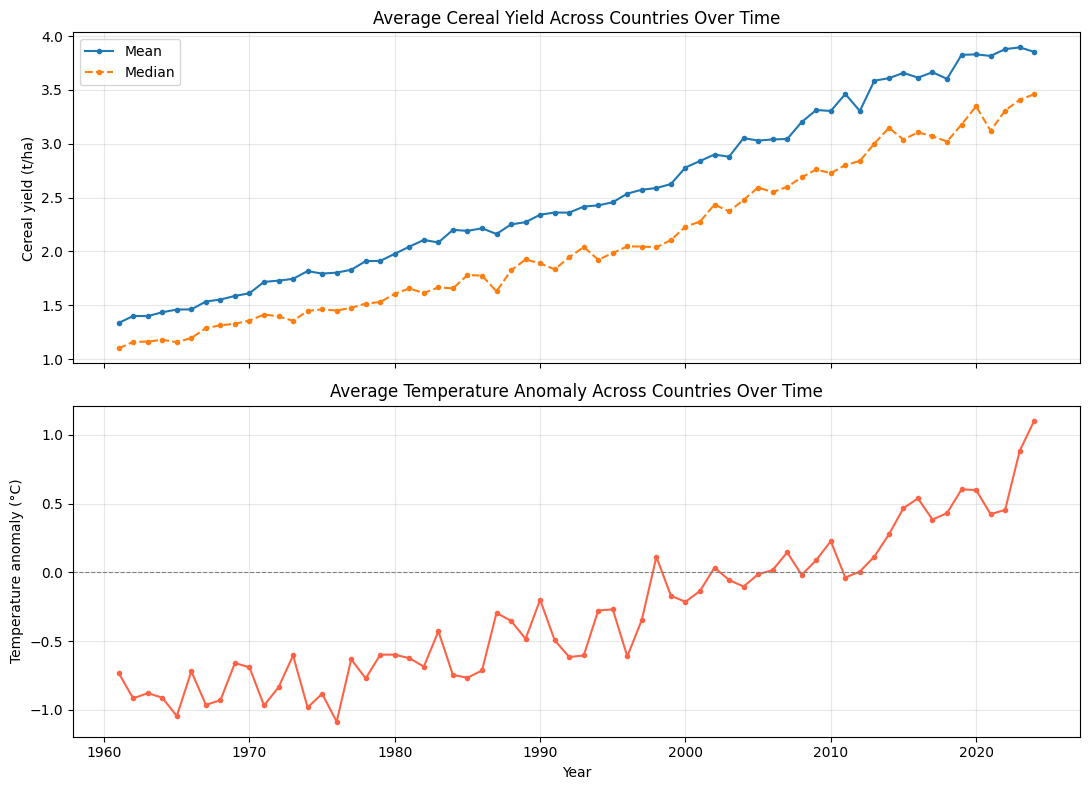

In [ ]:
yearly_summary = (
    merged
    .groupby("year", as_index=False)
    .agg(
        avg_yield_ton_ha        =("cereal_yield_ton_ha",  "mean"),
        median_yield_ton_ha     =("cereal_yield_ton_ha",  "median"),
        avg_temperature_anomaly =("temperature_anomaly",  "mean"),
        n_countries             =("country",              "nunique"),
    )
)

display(yearly_summary.head())

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(yearly_summary["year"], yearly_summary["avg_yield_ton_ha"],
             marker="o", markersize=3, label="Mean")
axes[0].plot(yearly_summary["year"], yearly_summary["median_yield_ton_ha"],
             linestyle="--", marker="o", markersize=3, label="Median")
axes[0].set_ylabel("Cereal yield (t/ha)")
axes[0].set_title("Average Cereal Yield Across Countries Over Time")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(yearly_summary["year"], yearly_summary["avg_temperature_anomaly"],
             color="tomato", marker="o", markersize=3)
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Temperature anomaly (°C)")
axes[1].set_xlabel("Year")
axes[1].set_title("Average Temperature Anomaly Across Countries Over Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "trends_over_time.png", dpi=150)
plt.show()

## 10. EDA — scatter plot and country time series

### Scatter plot coloured by decade

A raw scatter of yield vs temperature anomaly is dominated by the long-run upward trend
in both variables not the temperature effect. Colouring by year makes this confound
visible and motivates the need for fixed-effects models.

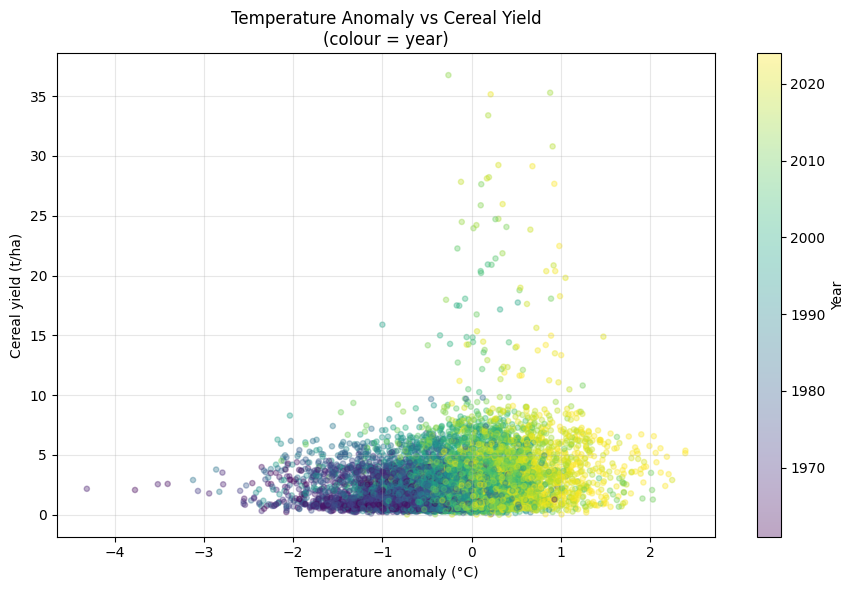

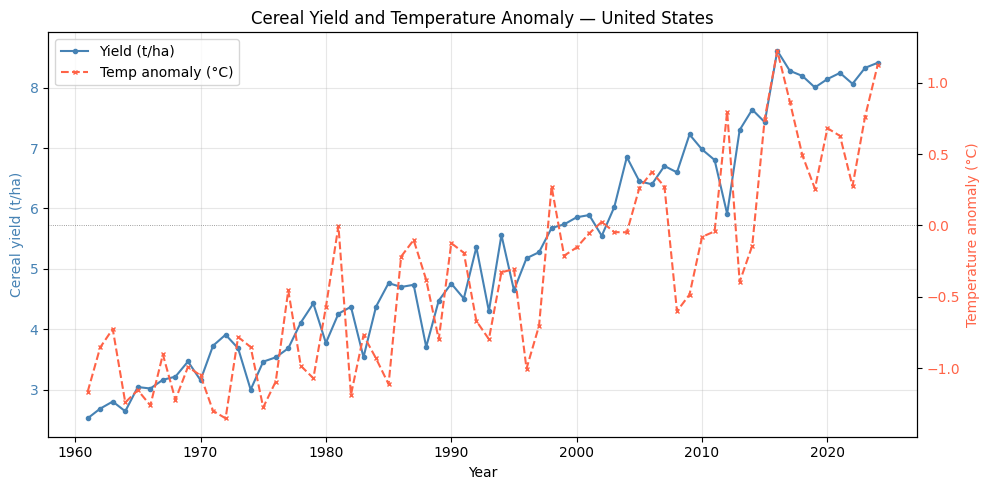

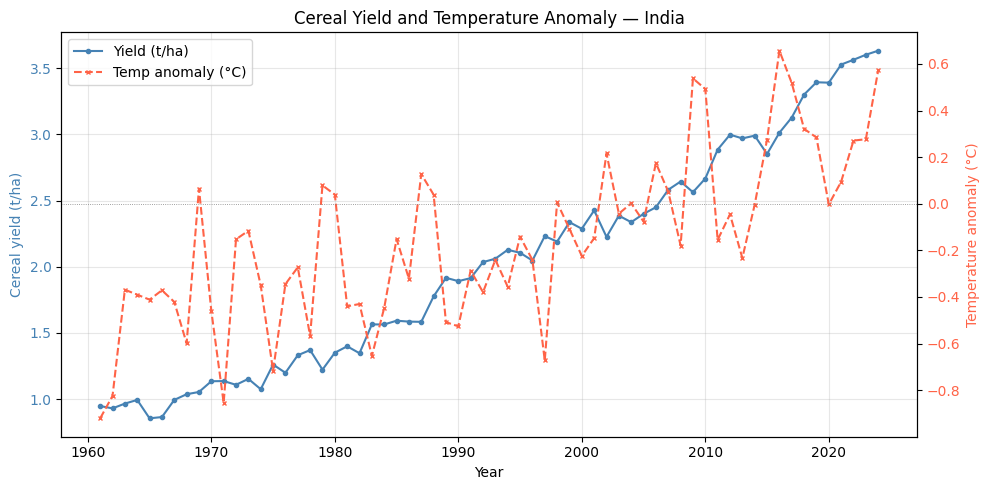

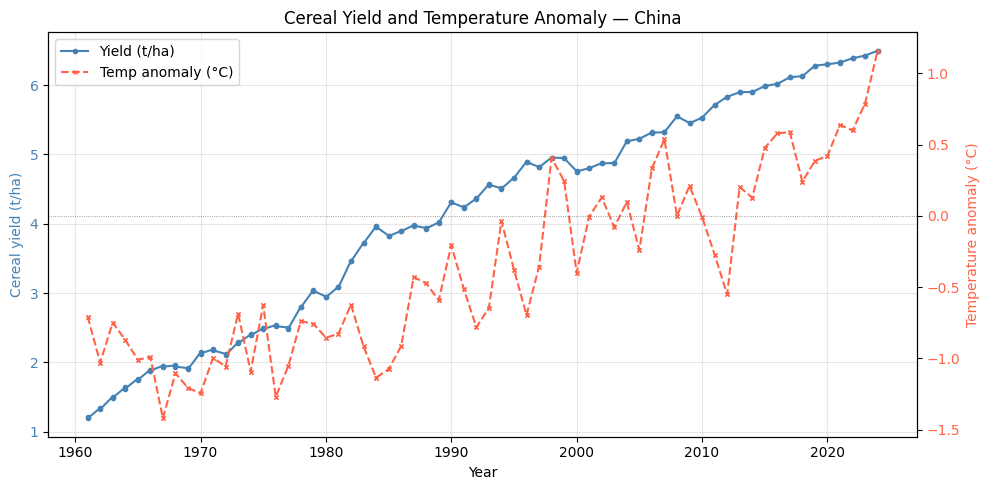

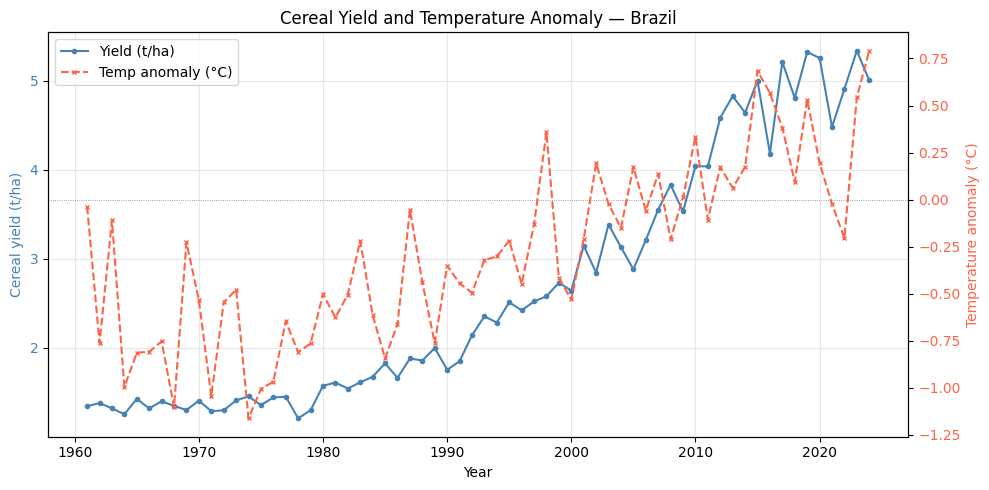

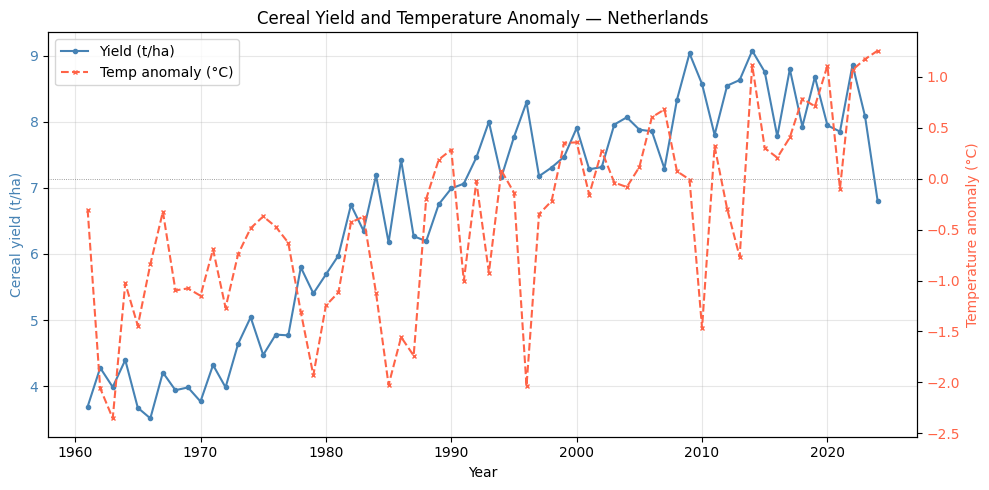

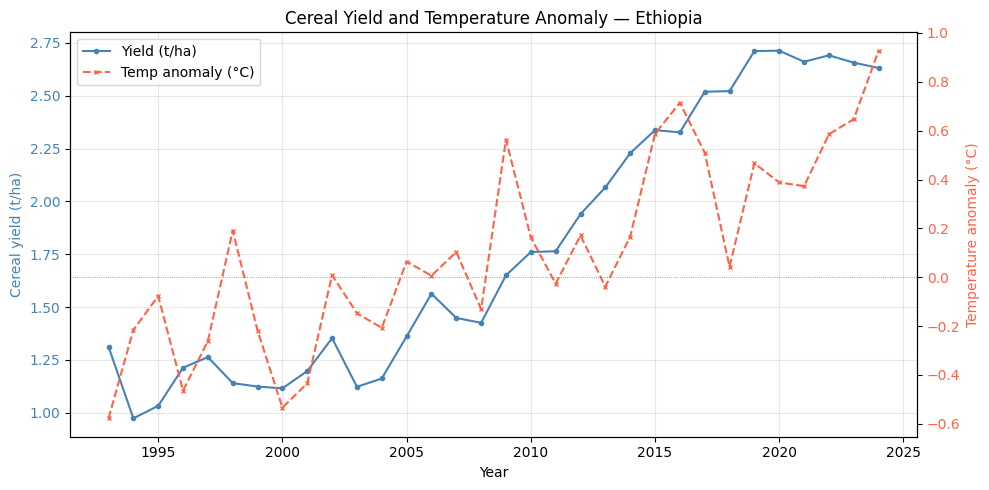

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    merged["temperature_anomaly"],
    merged["cereal_yield_ton_ha"],
    c=merged["year"], cmap="viridis",
    alpha=0.35, s=14,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Year")
ax.set_title("Temperature Anomaly vs Cereal Yield\n(colour = year)")
ax.set_xlabel("Temperature anomaly (°C)")
ax.set_ylabel("Cereal yield (t/ha)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "scatter_temperature_vs_yield.png", dpi=150)
plt.show()

# Selected country dual-axis time series.
selected_countries = ["United States", "India", "China", "Brazil", "Netherlands", "Ethiopia"]
available_countries = [c for c in selected_countries if c in set(merged["country"])]

for country in available_countries:
    cdf = merged[merged["country"].eq(country)].sort_values("year")

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(cdf["year"], cdf["cereal_yield_ton_ha"],
             marker="o", markersize=3, color="steelblue", label="Yield (t/ha)")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Cereal yield (t/ha)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(cdf["year"], cdf["temperature_anomaly"],
             linestyle="--", marker="x", markersize=3, color="tomato", label="Temp anomaly (°C)")
    ax2.axhline(0, color="grey", linewidth=0.6, linestyle=":")
    ax2.set_ylabel("Temperature anomaly (°C)", color="tomato")
    ax2.tick_params(axis="y", labelcolor="tomato")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax1.set_title(f"Cereal Yield and Temperature Anomaly — {country}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"timeseries_{country.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

## 11. Feature engineering

We add features that capture dynamics beyond the raw annual level:

| Feature | Description |
|---|---|
| `yield_change_pct` | Year-on-year % change in cereal yield within country |
| `temperature_anomaly_lag1` | Previous year's anomaly |
| `temperature_anomaly_lag2` | Anomaly two years earlier |
| `rolling_temp_anomaly_3yr` | 3-year rolling mean of anomaly (excludes current year) |
| `rolling_yield_3yr` | 3-year rolling mean of yield (excludes current year) |

The rolling averages use `.shift(1)` before `.rolling()` to avoid data leakage the
current year's value is never included in its own historical window.

In [ ]:
merged = merged.sort_values(["country", "year"]).copy()

merged["yield_change_pct"] = (
    merged.groupby("country")["cereal_yield_ton_ha"].pct_change() * 100
)

merged["temperature_anomaly_lag1"] = merged.groupby("country")["temperature_anomaly"].shift(1)
merged["temperature_anomaly_lag2"] = merged.groupby("country")["temperature_anomaly"].shift(2)

merged["rolling_temp_anomaly_3yr"] = (
    merged.groupby("country")["temperature_anomaly"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=2).mean())
)

merged["rolling_yield_3yr"] = (
    merged.groupby("country")["cereal_yield_ton_ha"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=2).mean())
)

# Save enhanced dataset.
merged.to_csv(MERGED_CSV, index=False)
merged.to_sql("merged_country_year", conn, if_exists="replace", index=False)

feature_cols = [
    "country", "year", "cereal_yield_ton_ha", "yield_change_pct",
    "temperature_anomaly", "temperature_anomaly_lag1", "temperature_anomaly_lag2",
    "rolling_temp_anomaly_3yr", "rolling_yield_3yr",
]
display(merged[feature_cols].head(10))
print("Rows after feature engineering:", merged.shape[0])

,country,year,cereal_yield_ton_ha,yield_change_pct,temperature_anomaly,temperature_anomaly_lag1,temperature_anomaly_lag2,rolling_temp_anomaly_3yr,rolling_yield_3yr
0,Afghanistan,1961,1.1151,NaN,-1.1939,NaN,NaN,NaN,NaN
1,Afghanistan,1962,1.0790,-3.2374,-1.3853,-1.1939,NaN,NaN,NaN
2,Afghanistan,1963,0.9858,-8.6376,-0.1189,-1.3853,-1.1939,-1.2896,1.0970
3,Afghanistan,1964,1.0828,9.8397,-2.1012,-0.1189,-1.3853,-0.8994,1.0600
4,Afghanistan,1965,1.0989,1.4869,-1.3173,-2.1012,-0.1189,-1.2018,1.0492
5,Afghanistan,1966,1.0123,-7.8806,-0.8837,-1.3173,-2.1012,-1.1791,1.0558
6,Afghanistan,1967,1.2245,20.9622,-1.4853,-0.8837,-1.3173,-1.4341,1.0647
7,Afghanistan,1968,1.2875,5.1450,-1.4714,-1.4853,-0.8837,-1.2288,1.1119
8,Afghanistan,1969,1.3104,1.7786,-0.9430,-1.4714,-1.4853,-1.2802,1.1748
9,Afghanistan,1970,1.1051,-15.6670,-0.0696,-0.9430,-1.4714,-1.2999,1.2741


Rows after feature engineering: 10028


## 12. Correlation analysis

Correlation is not causation, but it is a useful first check. We use seaborn's annotated
heatmap with a diverging colour scale so positive and negative correlations are
immediately distinguishable.

,cereal_yield_ton_ha,yield_change_pct,temperature_anomaly,temperature_anomaly_lag1,temperature_anomaly_lag2,rolling_temp_anomaly_3yr,rolling_yield_3yr
cereal_yield_ton_ha,1.0000,-0.0044,0.2292,0.2277,0.2175,0.2493,0.9578
yield_change_pct,-0.0044,1.0000,-0.0106,0.0132,0.0060,0.0069,-0.0169
temperature_anomaly,0.2292,-0.0106,1.0000,0.6803,0.6102,0.7292,0.2382
temperature_anomaly_lag1,0.2277,0.0132,0.6803,1.0000,0.6599,0.8690,0.2295
temperature_anomaly_lag2,0.2175,0.0060,0.6102,0.6599,1.0000,0.8840,0.2252
rolling_temp_anomaly_3yr,0.2493,0.0069,0.7292,0.8690,0.8840,1.0000,0.2580
rolling_yield_3yr,0.9578,-0.0169,0.2382,0.2295,0.2252,0.2580,1.0000


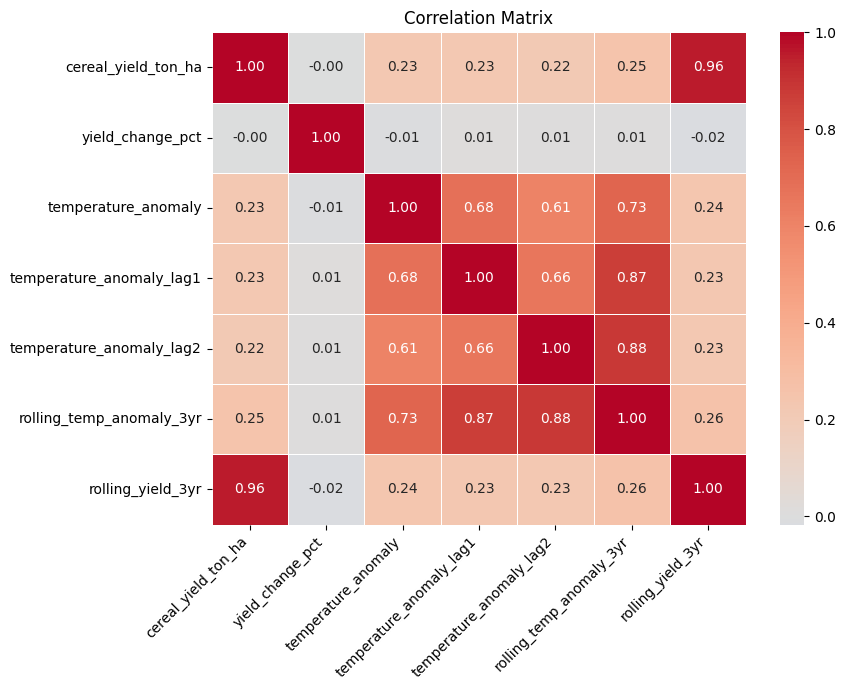

In [ ]:
corr_cols = [
    "cereal_yield_ton_ha",
    "yield_change_pct",
    "temperature_anomaly",
    "temperature_anomaly_lag1",
    "temperature_anomaly_lag2",
    "rolling_temp_anomaly_3yr",
    "rolling_yield_3yr",
]

corr_matrix = merged[corr_cols].corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_matrix.png", dpi=150)
plt.show()

## 13. Regression analysis

Three models in increasing methodological rigour:

| Model | Dependent variable | Controls | Why useful |
|---|---|---|---|
| 1. Naive | Yield level | Year | Baseline ignores country heterogeneity |
| 2. Country FE | Yield level | Year + country dummies | Compares variation *within* countries |
| 3. Change + FE | % yield change | Year + country dummies + lag anomaly | Focuses on short-run dynamics |

All models use heteroskedasticity-robust standard errors (`HC3`).

> Results should be interpreted as **associations**, not causal estimates.

In [ ]:
if STATSMODELS_AVAILABLE:
    # ── Model 1: naive level ──────────────────────────────────
    df_level = merged.dropna(subset=["cereal_yield_ton_ha", "temperature_anomaly", "year"]).copy()
    model1   = smf.ols("cereal_yield_ton_ha ~ temperature_anomaly + year", data=df_level).fit(cov_type="HC3")
    print("MODEL 1: Naive yield level model")
    print(model1.summary().tables[0])
    print(model1.summary().tables[1])

    # ── Model 2: country fixed effects ───────────────────────
    model2 = smf.ols(
        "cereal_yield_ton_ha ~ temperature_anomaly + year + C(country)",
        data=df_level,
    ).fit(cov_type="HC3")
    print("\n\nMODEL 2: Yield level model with country fixed effects")
    # Print only the first few rows of the parameter table to avoid printing all country dummies.
    summary2_params = model2.summary().tables[1]
    summary2_df = pd.DataFrame(summary2_params.data[1:], columns=summary2_params.data[0])
    print(model2.summary().tables[0])
    print(summary2_df.iloc[:5].to_string())  # temperature_anomaly and year rows only
    print(f"  ... ({len(summary2_df) - 5} country dummy rows not shown)")

    # ── Model 3: yield change + country FE ───────────────────
    df_change = merged.dropna(subset=[
        "yield_change_pct", "temperature_anomaly", "temperature_anomaly_lag1", "year"
    ]).copy()
    lo, hi = df_change["yield_change_pct"].quantile([0.01, 0.99])
    df_change = df_change[df_change["yield_change_pct"].between(lo, hi)].copy()
    model3 = smf.ols(
        "yield_change_pct ~ temperature_anomaly + temperature_anomaly_lag1 + year + C(country)",
        data=df_change,
    ).fit(cov_type="HC3")
    print("\n\nMODEL 3: Yield % change model with country fixed effects")
    print(model3.summary().tables[0])
    summary3_df = pd.DataFrame(model3.summary().tables[1].data[1:], columns=model3.summary().tables[1].data[0])
    print(summary3_df.iloc[:6].to_string())

    # ── Compact comparison table ─────────────────────────────
    key_results = pd.DataFrame({
        "model":                    ["naive_level", "fe_level", "fe_change"],
        "dependent_variable":       ["cereal_yield_ton_ha", "cereal_yield_ton_ha", "yield_change_pct"],
        "temperature_anomaly_coef": [
            model1.params.get("temperature_anomaly", np.nan),
            model2.params.get("temperature_anomaly", np.nan),
            model3.params.get("temperature_anomaly", np.nan),
        ],
        "temperature_anomaly_pvalue": [
            model1.pvalues.get("temperature_anomaly", np.nan),
            model2.pvalues.get("temperature_anomaly", np.nan),
            model3.pvalues.get("temperature_anomaly", np.nan),
        ],
        "n_observations": [int(m.nobs) for m in [model1, model2, model3]],
        "r_squared":      [m.rsquared for m in [model1, model2, model3]],
    })
    display(key_results)
    key_results.to_csv(OUTPUT_DIR / "regression_key_results.csv", index=False)
else:
    print("statsmodels not installed — regression skipped.")

MODEL 1: Naive yield level model
                             OLS Regression Results                            
Dep. Variable:     cereal_yield_ton_ha   R-squared:                       0.109
Model:                             OLS   Adj. R-squared:                  0.109
Method:                  Least Squares   F-statistic:                     549.5
Date:                 Wed, 22 Apr 2026   Prob (F-statistic):          3.62e-227
Time:                         10:16:51   Log-Likelihood:                -22316.
No. Observations:                10028   AIC:                         4.464e+04
Df Residuals:                    10025   BIC:                         4.466e+04
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

,model,dependent_variable,temperature_anomaly_coef,temperature_anomaly_pvalue,n_observations,r_squared
0,naive_level,cereal_yield_ton_ha,-0.0709,0.0966,10028,0.1093
1,fe_level,cereal_yield_ton_ha,0.0470,0.1012,10028,0.6806
2,fe_change,yield_change_pct,-1.3049,0.0027,9656,0.0185


## 14. Country sensitivity analysis

A within-country correlation between temperature anomaly and year-on-year yield change
helps identify where warmer-than-average years tend to coincide with yield gains or losses.
This is not a causal estimate, but it surfaces heterogeneity across climatic zones.

Most negative country-level correlations (warm years → lower yield):


,country,observations,corr_temp_anomaly_yield_change,avg_yield_ton_ha,avg_temperature_anomaly
69,Hong Kong,29,-0.3732,1.9781,-0.6691
72,Indonesia,63,-0.3265,3.6490,-0.3131
77,Italy,63,-0.2808,4.2197,-0.4337
76,Israel,63,-0.2672,2.6307,-0.3765
56,France,63,-0.2614,5.7386,-0.3998
48,Egypt,63,-0.2608,5.6430,-0.4414
62,Greece,63,-0.2546,3.3426,-0.2318
161,Uruguay,63,-0.2386,2.8422,-0.1522
99,Mexico,63,-0.2241,2.5852,-0.3624
168,Zimbabwe,63,-0.2167,1.0546,-0.2947



Most positive country-level correlations (warm years → higher yield):


,country,observations,corr_temp_anomaly_yield_change,avg_yield_ton_ha,avg_temperature_anomaly
162,Uzbekistan,32,0.3247,3.8661,0.2038
44,Djibouti,43,0.3054,1.8333,0.0019
3,Angola,63,0.2298,0.6657,-0.3073
127,Qatar,53,0.2279,4.8115,-0.3006
55,Finland,63,0.2181,2.9590,-0.5423
84,Kyrgyzstan,32,0.2174,2.6850,0.1368
12,Belarus,32,0.2149,2.8510,0.1570
129,Russia,32,0.1849,2.1577,0.1386
143,Sri Lanka,63,0.1600,2.9823,-0.1750
163,Vanuatu,63,0.1471,0.5318,-0.0946


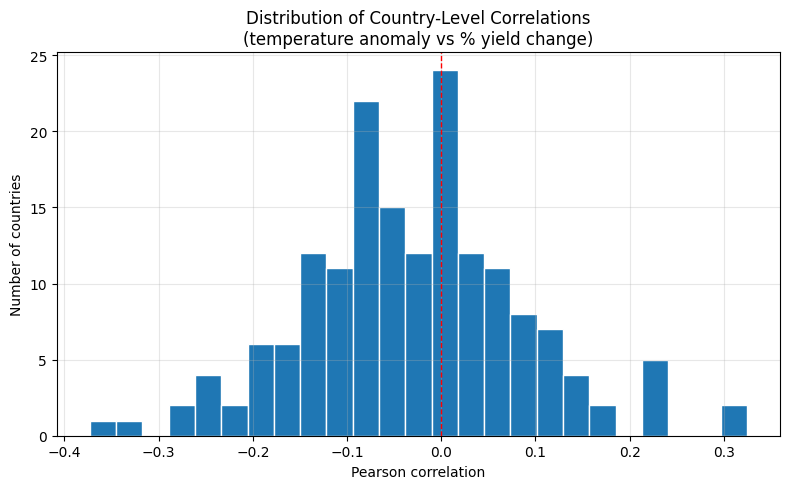

In [ ]:
country_sensitivity = []

for country, grp in merged.dropna(subset=["temperature_anomaly", "yield_change_pct"]).groupby("country"):
    if (len(grp) >= 20
            and grp["temperature_anomaly"].nunique() > 1
            and grp["yield_change_pct"].nunique() > 1):
        corr = grp["temperature_anomaly"].corr(grp["yield_change_pct"])
        country_sensitivity.append({
            "country":                          country,
            "observations":                     len(grp),
            "corr_temp_anomaly_yield_change":   corr,
            "avg_yield_ton_ha":                 grp["cereal_yield_ton_ha"].mean(),
            "avg_temperature_anomaly":          grp["temperature_anomaly"].mean(),
        })

country_sensitivity = pd.DataFrame(country_sensitivity).dropna()

print("Most negative country-level correlations (warm years → lower yield):")
display(country_sensitivity.sort_values("corr_temp_anomaly_yield_change").head(10))

print("\nMost positive country-level correlations (warm years → higher yield):")
display(country_sensitivity.sort_values("corr_temp_anomaly_yield_change", ascending=False).head(10))

country_sensitivity.to_csv(OUTPUT_DIR / "country_sensitivity.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(country_sensitivity["corr_temp_anomaly_yield_change"].dropna(), bins=25, edgecolor="white")
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_title("Distribution of Country-Level Correlations\n(temperature anomaly vs % yield change)")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("Number of countries")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "country_sensitivity_distribution.png", dpi=150)
plt.show()

## 15. Main findings and conclusion

- Cereal yields have risen steadily over the study period across most countries, primarily
  reflecting technological and agricultural improvements rather than climate alone.
- Temperature anomalies have also increased, indicating systematic warming relative to the
  historical baseline.
- The raw scatter plot appears noisy because it conflates the time trend in both variables.
  Colouring by year makes this confound visible.
- Country fixed-effects models are more appropriate because they compare variation *within*
  the same country over time, controlling for stable differences in agricultural systems,
  climate zones, and baseline productivity.
- The country sensitivity analysis reveals heterogeneous effects: some countries show a
  negative correlation between warmer years and yield changes (consistent with heat stress),
  while others show neutral or slightly positive correlations (possibly cold-climate
  countries where moderate warming extends the growing season).
- These results should **not** be interpreted as strict causal estimates. Yield is also
  determined by irrigation, fertiliser, technology, crop varieties, soil quality, pests,
  policy, and conflict.

**Answer to the research question:**

> Temperature anomalies are statistically associated with cereal yield outcomes, but the
> strength and direction of the relationship differ substantially across countries. Annual
> temperature anomalies are a relevant environmental feature for explaining yield variation
> within countries over time, yet they are insufficient on their own to explain global
> cereal yield levels.

## 16. Close database connection

In [ ]:
conn.close()
print("Database connection closed.")

Database connection closed.
